In [1]:
from brainsignals.plotting_convention import simplify_axes
%matplotlib inline

import os
import numpy as np
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import ScalarFormatter
import brainsignals.plotting_convention as pc

plt.rcParams.update({
    "figure.dpi": 600,
    "figure.figsize": (6, 2.5),
    "font.size": 8,
    "mathtext.fontset": "stix"
})

In [3]:
# Load vmem simulation data
base_dir = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/'
all_cell_models_folder = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/all_cells_folder/'
cell_names = os.listdir(all_cell_models_folder)

vmem_amp_file_paths = [
    os.path.join(base_dir, f'plot_imem_{cell_name}.npy')
    for cell_name in cell_names
]

vmem_amp_data_list = [
    np.load(path, allow_pickle=True).item()
    for path in vmem_amp_file_paths
]
vmem_amp_data = {}
for data in vmem_amp_data_list:
    vmem_amp_data.update(data)

# Load simulation data with full morphologies
base_dir = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/'

# Imem plot data for selected frequencies contains morphology information for plotting
morph_plot_file_paths = [
    os.path.join(base_dir, f'plot_imem_{cell_name}.npy')
    for cell_name in cell_names
]

# Load cdm simulation data

cdm_amp_file_paths = [
    os.path.join(base_dir, f'cdm_and_imem_data_neo_{cell_name}.npy')
    for cell_name in cell_names
]

cdm_amp_data_list = [
    np.load(path, allow_pickle=True).item()
    for path in cdm_amp_file_paths
]
cdm_amp_data = {}
for data in cdm_amp_data_list:
    cdm_amp_data.update(data)


In [4]:

file_paths = [
    os.path.join(base_dir,f"cdm_data_neocortical_{cell_name}.npy")
    for cell_name in cell_names
]

imem_data_list = [
    np.load(path, allow_pickle=True).item()
    for path in file_paths
]

imem_data = {}
for data in imem_data_list:

    imem_data.update(data)



#  example cells
get_idx_list = list(imem_data.keys())
selected_cells = ['L4_BP_bIR215_5', "L5_TTPC2_cADpyr232_3", "L5_MC_bAC217_1", 'L4_SS_cADpyr230_1', "L5_NGC_bNAC219_5"]
positions = {item: get_idx_list.index(item) for item in selected_cells if item in get_idx_list}

items_list = list(imem_data.items())
selected_items = [items_list[positions[cell]] for cell in selected_cells]

subset_imem_data = dict(selected_items)

In [5]:
# Can only load some selected cells at a time for plotting
def load_plot_data_from_files(selected_cells):
    """Loads data for the selected cells from multiple .npy files. Ensures effective loading without using too much RAM"""
    data = {}

    for cell_name in selected_cells:
        file_path = os.path.join(base_dir, f'plot_imem_{cell_name}.npy')
        temp_data = np.load(file_path, allow_pickle=True).item()  # Load the .npy dictionary
        if cell_name in temp_data:
            data[cell_name] = temp_data[cell_name]  # Store only required cell data

    return data

In [12]:
cell_names = {
    'L4_BP_bIR215_5': 'L4 Bipolar cell (BP)',
    "L5_MC_bAC217_1": "L5 Martinotti cell (MC)",
    "L5_TTPC2_cADpyr232_3": "L5 Pyramidal cell (TTPC)",
    "L5_NGC_bNAC219_5": "L5 Neurogliaform cell (NGC)",
    'L4_SS_cADpyr230_1': 'L4 Spiny Stellate cell (SS)'
}

short_cell_names = {
    'L4_BP_bIR215_5': 'L4 BP',
    "L5_MC_bAC217_1": "L5 MC",
    "L5_TTPC2_cADpyr232_3": "L5 TTPC",
    "L5_NGC_bNAC219_5": "L5 NGC",
    'L4_SS_cADpyr230_1': 'L4 SS'
}

cell_vmem_colors = {
    'L4_BP_bIR215_5': "salmon",
    "L5_MC_bAC217_1": 'tab:pink',
    "L5_TTPC2_cADpyr232_3": "tab:cyan",
    "L5_NGC_bNAC219_5": 'tab:brown',
    'L4_SS_cADpyr230_1': "darkviolet",
}

cell_cdm_colors = {
    'L4_BP_bIR215_5':   "gray", #"tab:orange",
    "L5_MC_bAC217_1": "gray", #"tab:blue",
    "L5_TTPC2_cADpyr232_3": "gray", # "tab:green",
    "L5_NGC_bNAC219_5":  "gray", #'tab:red',
    'L4_SS_cADpyr230_1': "gray", #'tab:purple'
}

cell_cdm_up_down_colors = {
    'L4_BP_bIR215_5':  "gray", #"#A95400",  # darker/desaturated orange
    "L5_TTPC2_cADpyr232_3":  "gray", #"#1A5A1D",  # darker/desaturated green
    'L4_SS_cADpyr230_1':  "gray", #"#51306A",  # darker/desaturated purple
    "L5_MC_bAC217_1":    "gray", #"#004466",  # dark blue variant
    "L5_NGC_bNAC219_5":  "gray", #"coral",  # darker vermillion (still not orange)
}


# Imem at time t max pz

In [23]:
def plot_imem_figure_neo(avg_imem_data_dict,
                         selected_cells=None, xlim1=(0, 0.0003), xlim2=(0.0018, None)):

    # --- Load your Imem amplitude & phase data ---
    imem_amp_dict = load_plot_data_from_files(selected_cells)
    if selected_cells:
        unique_cells = [cell for cell in selected_cells if cell in imem_amp_dict]
    num_cells = len(unique_cells)
    assert num_cells == 5, "This layout assumes exactly 5 cells (5 rows)."

    # --- Figure layout ---
    fig = plt.figure(figsize=(10, 15))
    gs = gridspec.GridSpec(5, 2, width_ratios=[2.5, 1.5],
                           height_ratios=[1, 1, 1, 1, 1],
                           wspace=0.2, hspace=0.4)

    freq_colors = ['tab:blue', 'tab:orange', 'tab:green']

    # ================================================
    # LEFT COLUMN: scatter of instantaneous Imem(t_max)
    # ================================================
    for i, label in enumerate(unique_cells):

        cell_data = imem_amp_dict[label]
        x = np.array(cell_data['x'])
        z = np.array(cell_data['z'])
        totnsegs = cell_data['totnsegs']
        freqs = np.array(cell_data['freqs'])
        area = cell_data['area']

        imem_amps = np.array(cell_data['imem_amps'])      # shape: (seg, freq)
        imem_phases = np.array(cell_data['imem_phases'])   # shape: (seg, freq)

        amp_data = avg_imem_data_dict[label]
        amp_freqs = np.array(amp_data['frequency'])
        input_current_phases = amp_data['input_current_phase'] 
        cdm_amps = np.array(amp_data['cdm'])  
        cdm_phases = np.array(amp_data['cdm_phase'])  
        z_coords = z.mean(axis=-1)

        # Compute t_max for each frequency
        t_max_dict = {}

        # Find direction of pz at 1 Hz
        input_current_phase_0 = input_current_phases[0]
        t_max_inp_0 = (3*np.pi/2 - input_current_phase_0) / (2*np.pi* amp_freqs[0])
        cdm_amp_0 = cdm_amps[0]
        cdm_phase_0 = cdm_phases[0]
        cdm_value_0 = cdm_amp_0 * np.sin(2*np.pi* amp_freqs[0] *t_max_inp_0 + cdm_phase_0)
        if cdm_value_0 < 0:
            t_max_cdm_sign = 3
        else:
            t_max_cdm_sign = 1
        # Find the time of maximum pz
        for f in freqs:

            f_idx = np.argmin(np.abs(freqs - f))
            T = 1 / f * 1000 * 1
            t_ = np.linspace(0, T, 100)



            # Find pz above and below at t max
            #f_idx = np.argmin(np.abs(amp_freqs - f))


            cdm_amp = cdm_amps[f_idx]
            cdm_phase = cdm_phases[f_idx]
            
            t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)

            while t_max_cdm < 0:
                t_max_cdm += 1.0 / f

            t_max_dict[f] = t_max_cdm

        # ---- Sub-panels: morphology + two-axis scatter ----
        left_ratio = 1.2
        right_ratio = 1.8

        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=gs[i, 0],
            width_ratios=[left_ratio, right_ratio], wspace=0.2
        )

        ax_morph = fig.add_subplot(inner_gs[0])
        #ax_left = fig.add_subplot(inner_gs[1])
        ax_right = fig.add_subplot(inner_gs[1])

        # --- Morphology ---
        for idx in range(totnsegs):
            ax_morph.plot(x[idx], z[idx], c=cell_vmem_colors[label], lw=1)

        ax_morph.plot(x.mean(axis=-1)[0], z.mean(axis=-1)[0],
                      'o', color='black', markersize=2)

        ax_morph.set_title(f'{cell_names[label]}', fontsize=10)
        ax_morph.set_xticks([])
        ax_morph.set_yticks([])
        x_lab = np.min(x) - 50
        if "L5_NGC" in label:
            ax_morph.plot([x_lab, x_lab], [np.min(z), np.min(z) + 200], clip_on=False, c='k', lw=1)
            ax_morph.text(x_lab - 25, 0, "200\nµm", va='center', ha="right")

        else:
            ax_morph.plot([x_lab, x_lab], [0, -200], clip_on=False, c='k', lw=1)
            ax_morph.text(x_lab - 25, -100, "200\nµm", va='center', ha="right")
        ax_morph.set_frame_on(False)
        ax_morph.set_aspect('equal')

        if label == 'L4_BP_bIR215_5':
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-150, np.max(x.mean(axis=-1))+150)
        elif label in ["L5_MC_bAC217_1", "L5_TTPC2_cADpyr232_3"]:
            ax_morph.set_xlim(np.min(x.mean(axis=-1))-50, np.max(x.mean(axis=-1))+50)

        # --- Scatter instantaneous Imem(t_max) ---
        for f_idx, f in enumerate(freqs):

            T = 1 / f * 1000 * 1
            t_ = np.linspace(0, T, 100)

            input_phase = input_current_phases[f_idx]
            im_amp = imem_amps[:, f_idx]
            im_phase = imem_phases[:, f_idx] - input_phase

            pz_amp = cdm_amps[f_idx]
            pz_phase = cdm_phases[f_idx] - input_phase

            pz = pz_amp * np.sin(2 * np.pi * f * t_ / 1000 + pz_phase)
            t_pz_max_idx = np.argmax(pz)
            t_pz_max = t_[t_pz_max_idx]

            im = np.array([im_amp[c_idx] * np.sin(2 * np.pi * f * t_ / 1000 + im_phase[c_idx])
                       for c_idx in range(im_amp.shape[0])])
            im_soma = im[0, :].copy()
            im_t_max = im[:, t_pz_max_idx]

            if im_soma[t_pz_max_idx] > 0:
                im_t_max *= -1

            im_t_max_density = im_t_max / area

            # Marker styling unchanged
            if f == 10:
                marker, size, alpha = 'o', 20, 0.8
            elif f == 100:
                marker, size, alpha = 'x', 10, 0.8
            else:
                marker, size, alpha = '^', 6, 0.5


            ax_right.scatter(
                im_t_max_density, z_coords,
                label=f'{f} Hz', alpha=alpha, marker=marker,
                color=freq_colors[f_idx], s=size
            )

        # --- Axis settings ---
        #ax_left.axvline(0, color='black', linestyle=':')
        ax_right.axvline(0, color='black', linestyle=':')

        if i == 1:
            ax_right.legend(loc='upper left', fontsize=8)

        ax_right.set_ylabel('$z$ [µm]', fontsize=10)
        pc.simplify_axes(ax_right)
    fig.text(0.47, 0.07, r'current density at $t_{\rm max}$ [nA/µm³]', ha='center', fontsize=10)

    # =======================================================
    # RIGHT COLUMN: λ_AC and p_z frequency plots (unchanged)
    # =======================================================

    for i, cell_name in enumerate(unique_cells):

        ax_right_cell = fig.add_subplot(gs[i, 1])
        cell_info = avg_imem_data_dict[cell_name]
        frequency = cell_info['frequency']
        avg_pos_above = cell_info['avg_return_pos_above_soma']
        avg_pos_below = cell_info['avg_return_pos_below_soma']
        cdm_amps = cell_info['cdm']
        cdm_phases = cell_info['cdm_phase']
        cdm_pos_amps = cell_info['cdm_pos']
        cdm_neg_amps = cell_info['cdm_neg']
        cdm_pos_phases = cell_info['cdm_phase_pos']
        cdm_neg_phases = cell_info['cdm_phase_neg']
        input_current_phases = cell_info['input_current_phase']

        ax_right_cell.axhline(0, color = 'dimgray', linestyle = (0, (6,1)), linewidth=0.8)

        # ======== First axis: λ_AC ========
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_above[:-1],
            label=r'$\lambda_{\rm AC}$ above',
            color='k',#cell_vmem_colors[cell_name],
            linestyle=':'
        )
        ax_right_cell.semilogx(
            frequency[:-1], avg_pos_below[:-1],
            label=r'$\lambda_{\rm AC}$ below',
            color='k',#cell_vmem_colors[cell_name],
            linestyle='--'
        )

        #ax_right_cell.set_title(f'{short_cell_names[cell_name]}', fontsize=10)
        ax_right_cell.set_xlim(1, 2000)
        lam_ylim = 1.2*max(np.max(avg_pos_above), np.max(np.abs(avg_pos_below)))
        ax_right_cell.set_ylim(-lam_ylim, lam_ylim)
        #ax_right_cell.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.8)
        #ax_right_cell.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.8)
        ax_right_cell.set_ylabel(r'$\lambda_{\rm AC}$ [µm]', fontsize=11, color='k')#cell_vmem_colors[cell_name])
        ax_right_cell.tick_params(axis='y', labelcolor='k')#cell_vmem_colors[cell_name])
        
        # ======== Second axis: CDM p_z ========
        ax2 = ax_right_cell.twinx()
        ax_right_cell.grid(False)
        ax2.grid(False)
        cdm_max_values = []
        cdm_values_pos = []
        cdm_values_neg = []
        for f_idx, f in enumerate(frequency):

            T = 1 / f * 1000 * 1
            t_ = np.linspace(0, T, 100)

            input_phase = input_current_phases[f_idx]
            # im_amp = imem_amps[:, f_idx]
            # im_phase = imem_phases[:, f_idx] - input_phase

            pz_amp = cdm_amps[f_idx]
            pz_pos_amp = cdm_pos_amps[f_idx]
            pz_neg_amp = cdm_neg_amps[f_idx]
            pz_phase = cdm_phases[f_idx] - input_phase
            pz_pos_phase = cdm_pos_phases[f_idx] - input_phase
            pz_neg_phase = cdm_neg_phases[f_idx] - input_phase

            pz = pz_amp * np.sin(2 * np.pi * f * t_ / 1000 + pz_phase)
            pz_pos = pz_pos_amp * np.sin(2 * np.pi * f * t_ / 1000 + pz_pos_phase)
            pz_neg = pz_neg_amp * np.sin(2 * np.pi * f * t_ / 1000 + pz_neg_phase)

            t_pz_max_idx = np.argmax(pz)
            t_pz_max = t_[t_pz_max_idx]

            #input_phase = input_current_phases[f_idx]
            #t_max_inp = (3*np.pi/2 - input_phase)/(2*np.pi*f)

            #cdm_amp = cdm_amps[f_idx]
            #cdm_phase = cdm_phases[f_idx]
            #cdm_value = cdm_amp * np.sin(2*np.pi*f*t_max_inp + cdm_phase)

            #if f_idx == 0:
            #    if cdm_value < 0:
            #        t_max_cdm_sign = 3
            #    else:
            #        t_max_cdm_sign = 1
            
            #t_max_cdm = (t_max_cdm_sign * np.pi/2 - cdm_phase)/(2*np.pi*f)
            #t_max_cdm = (np.pi/2 - cdm_phase)/(2*np.pi*f)

            cdm_max_value = np.abs(pz[t_pz_max_idx])#cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_max_value_pos = np.abs(pz_pos[t_pz_max_idx])#cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)
            cdm_max_value_neg = -np.abs(pz_neg[t_pz_max_idx])#cdm_amp * np.sin(2*np.pi*f*t_max_cdm + cdm_phase)

            if np.abs(cdm_max_value_neg) > np.abs(cdm_max_value_pos):
                cdm_max_value *= -1

            cdm_max_values.append(cdm_max_value)
            cdm_values_pos.append(cdm_max_value_pos)
            cdm_values_neg.append(cdm_max_value_neg)

            #print(f"Check: {cdm_max_value - cdm_value_pos + cdm_value_neg}")
        freq_idx_1Hz = np.argmin(np.abs(frequency - 1))
        freq_idx_1000Hz = np.argmin(np.abs(frequency - 1000))
        print(cell_name, np.array(frequency)[freq_idx_1Hz], np.array(cdm_max_values)[freq_idx_1Hz])
        print(cell_name, np.array(frequency)[freq_idx_1000Hz], np.array(cdm_max_values)[freq_idx_1000Hz])
        ax2.semilogx(
            frequency[:-1], cdm_max_values[:-1],
            label=r'$p_z$ total',
            color=cell_cdm_colors[cell_name], linestyle='-', lw=0.8,
        )
        ax2.semilogx(
            frequency[:-1], cdm_values_pos[:-1],
            label=r'$p_z$ above',
            color=cell_cdm_up_down_colors[cell_name], linestyle=':'
        )
        ax2.semilogx(
            frequency[:-1], cdm_values_neg[:-1],
            label=r'$p_z$ below',
            color=cell_cdm_up_down_colors[cell_name],
            linestyle='--'
        )

        ax2.set_xlim(1, 2000)
        cdm_ylim = 1.2*max(np.max(cdm_values_pos), np.max(np.abs(cdm_values_neg)))
        ax2.set_ylim(-cdm_ylim, cdm_ylim)
        ax2.set_ylabel(r'$p_z$ [nA·µm]', fontsize=11, color = 'gray')#cell_cdm_colors[cell_name])
        ax2.tick_params(axis='y', labelcolor=cell_cdm_colors[cell_name])

        # ======== Combined legend ========
        h1, l1 = ax_right_cell.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        
        if cell_name == 'L4_SS_cADpyr230_1':
            loc = 'center left'
        elif cell_name == 'L5_NGC_bNAC219_5':
            loc = 'center'
        elif cell_name == 'L5_TTPC2_cADpyr232_3':
            loc = 'lower right'
        else:
            loc = 'best'

        ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc=loc,
                frameon=True, fancybox=True, framealpha=0.9, ncol =2)

    fig.text(0.78, 0.07, 'frequency [Hz]', ha='center', fontsize=10)

    fig.text(0.14, 0.91, 'A', fontsize=12, fontweight='bold')
    fig.text(0.33, 0.91, 'B', fontsize=12, fontweight='bold')
    fig.text(0.62, 0.91, 'C', fontsize=12, fontweight='bold')

    plt.savefig('fig7_R1.pdf', bbox_inches='tight')
    #plt.show()


L4_BP_bIR215_5 1.0 -1.1981454650230994
L4_BP_bIR215_5 1000.0 -0.08153339149380616
L5_TTPC2_cADpyr232_3 1.0 1.042972159693094
L5_TTPC2_cADpyr232_3 1000.0 0.04598793222007059
L5_MC_bAC217_1 1.0 -0.3376468437039009
L5_MC_bAC217_1 1000.0 -0.09075179175402093
L4_SS_cADpyr230_1 1.0 0.06641336764911715
L4_SS_cADpyr230_1 1000.0 0.01569672508938373
L5_NGC_bNAC219_5 1.0 0.02005286112582318
L5_NGC_bNAC219_5 1000.0 0.025328506526859355


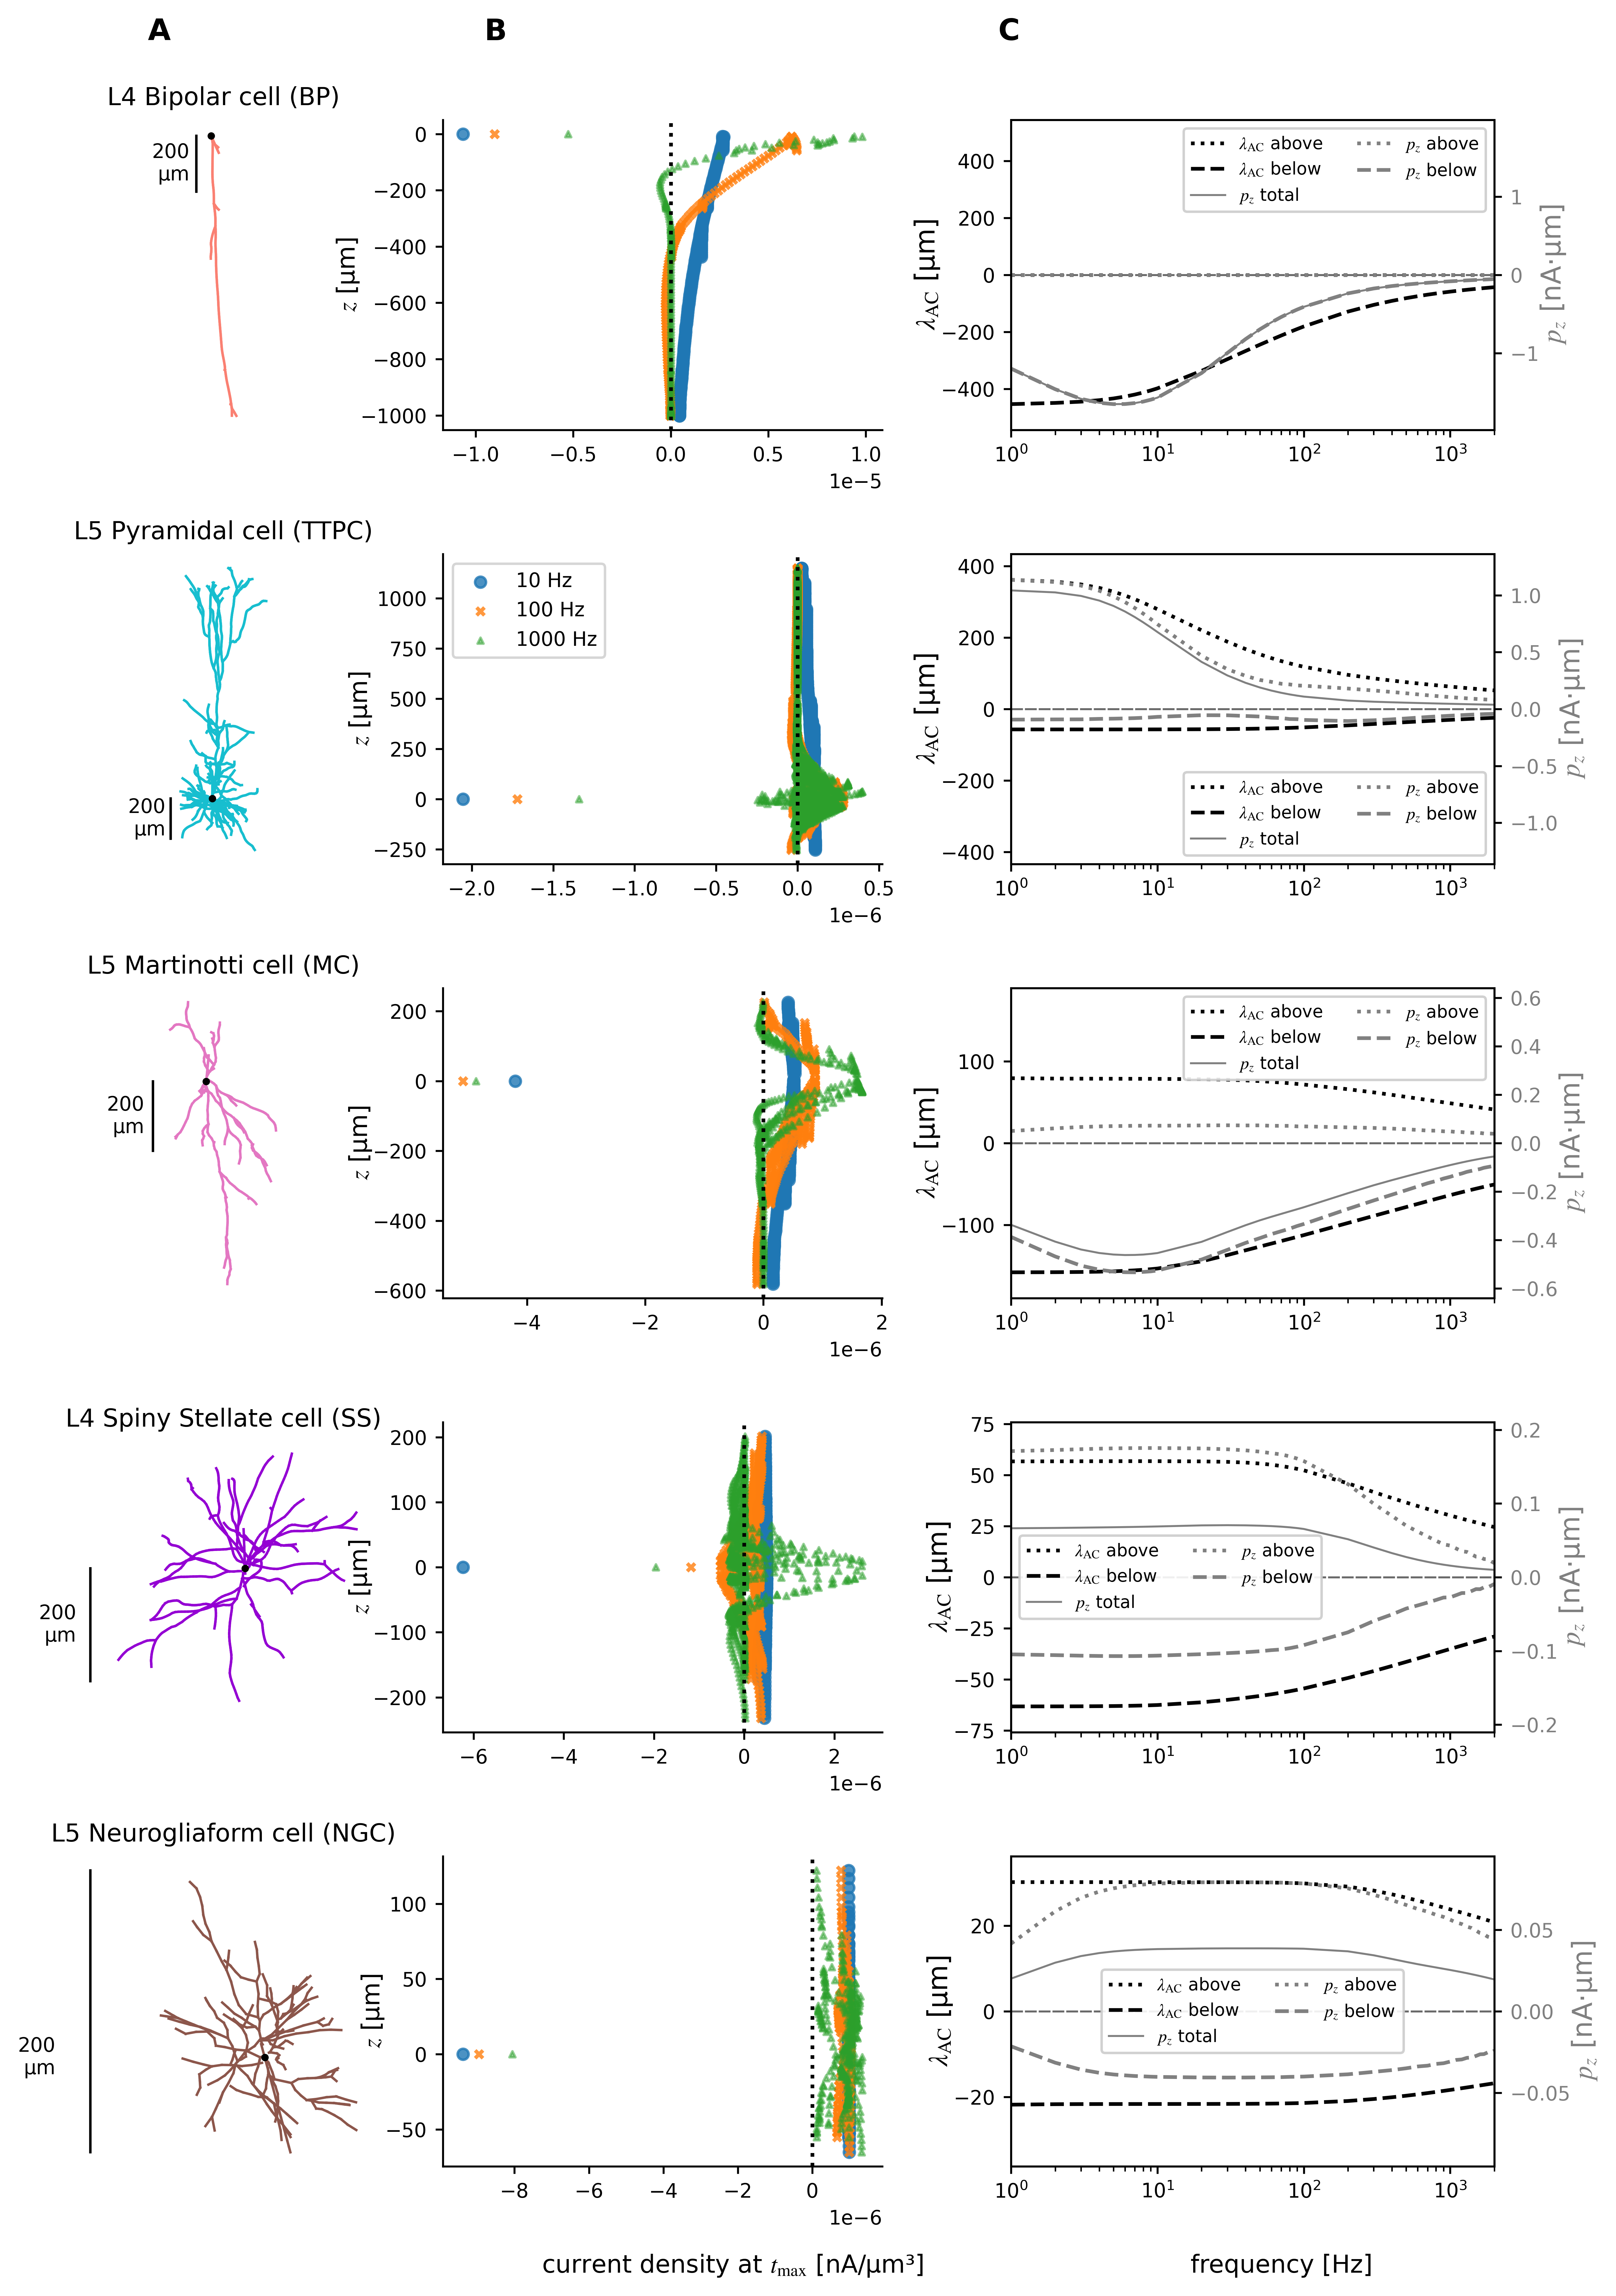

In [24]:
plot_imem_figure_neo(subset_imem_data, selected_cells=selected_cells, xlim1=(None, -1.9e-4),
                     xlim2=(-1.2e-5, 1.e-5))